<a href="https://colab.research.google.com/github/SarveshMD/colab-notebooks/blob/main/FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import time

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

Using cuda


In [3]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.9MB/s]


In [4]:
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [5]:
class_labels = train_data.classes
len(train_data), len(test_data)

(60000, 10000)

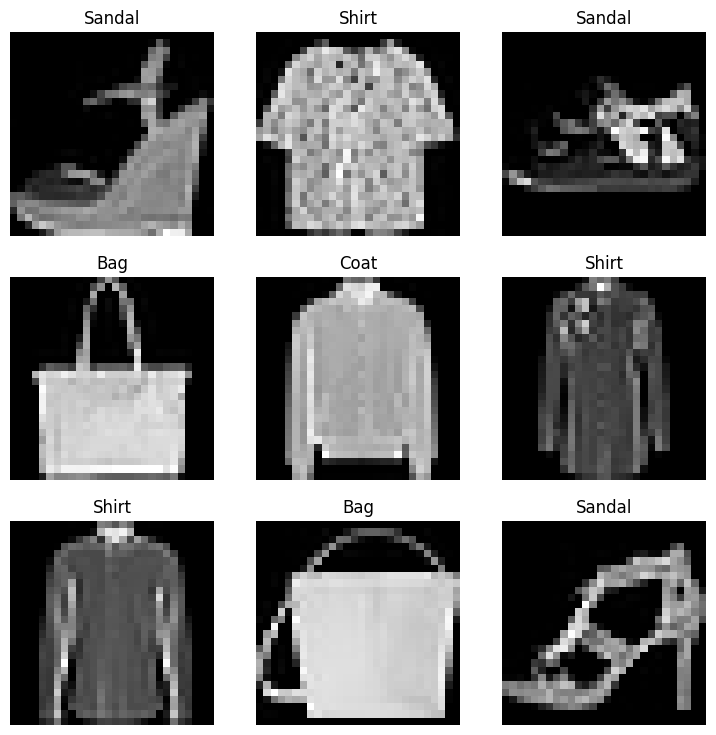

In [6]:
seed = 13
torch.manual_seed(seed)
class_map = train_data.classes
fig = plt.figure(figsize=(9,9))
rows, cols = 3, 3

for i in range(9):
    rand_idx = torch.randint(0, len(train_data), [1]).item()
    image, label = train_data[rand_idx]
    fig.add_subplot(rows, cols, i+1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_map[label])
    plt.axis(False)

In [7]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [8]:
torch.manual_seed(13)
train_data, val_data = random_split(
    train_data,
    [5/6, 1/6]
)
print(len(train_data), len(val_data))

50000 10000


In [9]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(test_data, batch_size=64, num_workers=2, pin_memory=True)

print(next(iter(train_dataloader))[0].shape)

torch.Size([64, 1, 28, 28])


In [10]:
criterion = nn.CrossEntropyLoss()

In [23]:
def train_model(model, epochs, criterion, optimizer, train_dataloder, val_dataloader, scheduler=None, device=device):
    train_losses = []
    val_losses = []
    val_accuracies = []
    best_params_dict = None
    best_val_loss = float('infinity')
    model.to(device)

    start = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for X, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            running_train_loss += loss.item()
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step()
        train_loss = running_train_loss / len(train_dataloader)
        train_losses.append(train_loss)

        model.eval()
        correct = 0
        total = 0
        running_val_loss = 0.0
        with torch.inference_mode():
            for X, y in val_dataloader:
                X, y = X.to(device), y.to(device)
                pred_logits = model(X)
                loss = criterion(pred_logits, y)
                predictions = torch.argmax(pred_logits, dim=1)
                total += y.size(0)
                correct += (y == predictions).sum().item()
                running_val_loss += loss.item()
        val_loss = running_val_loss / len(val_dataloader)
        val_losses.append(val_loss)
        acc = correct / total
        val_accuracies.append(acc)
        if scheduler is not None:
            curr_lr = f"{scheduler.get_last_lr()[0]:.4f}"
        else:
            curr_lr = "N/A"
        print(f"Epoch: {epoch+1}/{epochs} | Train Loss: {train_loss} | Val Loss: {val_loss} | Val Accuracy: {acc} | LR: {curr_lr}")
        if (val_loss < best_val_loss):
            best_val_loss = val_loss
            best_params_dict = model.state_dict()
            print(f"Best Val Loss: {val_loss} | Saving state_dict...")

    end = time.perf_counter()

    elapsed = end - start
    minutes, seconds = divmod(elapsed, 60)
    print(f"Total Training Time: {minutes}m {seconds:.2f}s")
    return best_params_dict, train_losses, val_losses, val_accuracies, elapsed

In [24]:
def plot_results(train_losses, val_losses, val_accuracies):
    fig, ax = plt.subplots(1, 2)
    ax[0].plot(train_losses, label="Train Losses")
    ax[0].plot(val_losses, label="Val Losses")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("Epoch vs Loss")
    ax[0].legend()

    ax[1].plot(val_accuracies, label="Val Accuracies")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].set_title("Epoch vs Validation Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

In [25]:
def run_test(model, best_state_dict, test_dataloader, loss_fn, device=device):
    model.load_state_dict(best_state_dict)
    model.to(device)
    model.eval()
    predicted_labels = []
    true_labels = []
    total_test_loss = 0.0
    with torch.inference_mode():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            total_test_loss += loss_fn(logits, y).item()
            preds = torch.argmax(logits, dim=1)
            predicted_labels.extend(preds.cpu().tolist())
            true_labels.extend(y.cpu().tolist())
    acc = accuracy_score(true_labels, predicted_labels)
    cm = confusion_matrix(true_labels, predicted_labels)
    print(classification_report(true_labels, predicted_labels))
    print(f"Test Accuracy: {acc:.2f} | Test Loss: {total_test_loss/len(test_dataloader):.4f}")
    disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
    disp.plot()

    plt.show()
    return acc

In [26]:
def reset_model_params(model):
    torch.manual_seed(13)
    model.apply(
        lambda m: m.reset_parameters()
        if hasattr(m, "reset_parameters")
        else None
    )

In [27]:
torch.manual_seed(13)
model_1 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(64*7*7, 1024),
    nn.ReLU(),

    nn.Linear(1024, 512),
    nn.ReLU(),

    nn.Linear(512, 10)
)

model_1.optimizers = [torch.optim.AdamW(params=model_1.parameters(), lr=1e-3, weight_decay=1e-5)]

In [28]:
torch.manual_seed(13)

model_2 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(64, 10)
)

model_2.optimizers = [torch.optim.SGD(params=model_2.parameters(), lr=0.05, momentum=0.9),
                      torch.optim.SGD(params=model_2.parameters(), lr=0.1, momentum=0.9),
                      torch.optim.AdamW(params=model_2.parameters(), lr=1e-2, weight_decay=1e-5)]

In [29]:
torch.manual_seed(13)

model_3 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(64, 10)
)

model_3.optimizers = [torch.optim.AdamW(params=model_3.parameters(), lr=1e-3, weight_decay=1e-3)]

In [30]:
torch.manual_seed(13)

model_4 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.AdaptiveAvgPool2d(2),
    nn.Flatten(),
    nn.Linear(256, 128),
    nn.ReLU(),

    nn.Linear(128, 10)
)

model_4.optimizers = [torch.optim.AdamW(params=model_4.parameters(), lr=1e-3, weight_decay=1e-5)]

> To improve the models
* Almost all models could do better with more epochs of training
* Should pick the best model and the best optimizer

### What to do next:
* Use model 1 architecture
* Use AdamW with 1e-3 learning rate (same as model 1)
* Add Dropout layer
* Add Data Augmentation to train_data
* Implement learning rate scheduler

In [31]:
torch.manual_seed(13)

model_5 = nn.Sequential( # just dropout with model_1
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(64*7*7, 1024),
    nn.ReLU(),

    nn.Linear(1024, 512),
    nn.ReLU(),

    nn.Dropout(p=0.3),
    nn.Linear(512, 10)
)

model_5.optimizers = [torch.optim.AdamW(params=model_5.parameters(), lr=5e-4, weight_decay=1e-5)]
model_5.lr_scheduler =  torch.optim.lr_scheduler.CosineAnnealingLR

# lr_scheduler

In [32]:
torch.manual_seed(13)

model_6 = nn.Sequential( # smaller fully connected network than model_5, dropout of 0.4
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(64*7*7, 256),
    nn.ReLU(),

    nn.Dropout(p=0.4),
    nn.Linear(256, 10)
)

model_6.optimizers = [torch.optim.AdamW(params=model_6.parameters(), lr=5e-4, weight_decay=1e-5)]
model_6.lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR

In [33]:
models = {
    "Model 1": model_1,
    "Model 2": model_2,
    "Model 3": model_3,
    "Model 4": model_4,
    "Model 5": model_5,
    "Model 6": model_6
}
model_stats = {
    "Model": [],
    "Optimizer": [],
    "Accuracy": [],
    "Train Time": []
}



-------------------  Model 1, Optimizer 0  ---------------------


Epoch 1/15: 100%|██████████| 782/782 [00:09<00:00, 82.31it/s] 


Epoch: 1/15 | Train Loss: 0.4022938016316165 | Val Loss: 0.2783901705673546 | Val Accuracy: 0.8988 | LR: N/A
Best Val Loss: 0.2783901705673546 | Saving state_dict...


Epoch 2/15: 100%|██████████| 782/782 [00:09<00:00, 83.72it/s] 


Epoch: 2/15 | Train Loss: 0.26722103119125146 | Val Loss: 0.24250183496505592 | Val Accuracy: 0.9163 | LR: N/A
Best Val Loss: 0.24250183496505592 | Saving state_dict...


...

Epoch: 13/15 | Train Loss: 0.05023201626976785 | Val Loss: 0.3529941334869641 | Val Accuracy: 0.9234 | LR: N/A


Epoch 14/15: 100%|██████████| 782/782 [00:08<00:00, 95.17it/s] 


Epoch: 14/15 | Train Loss: 0.04354685554941854 | Val Loss: 0.31526271246705845 | Val Accuracy: 0.9278 | LR: N/A


Epoch 15/15: 100%|██████████| 782/782 [00:08<00:00, 90.68it/s]


Epoch: 15/15 | Train Loss: 0.03794532513551568 | Val Loss: 0.3650947733883076 | Val Accuracy: 0.9217 | LR: N/A
Total Training Time: 2.0m 44.47s
Model Training Done...



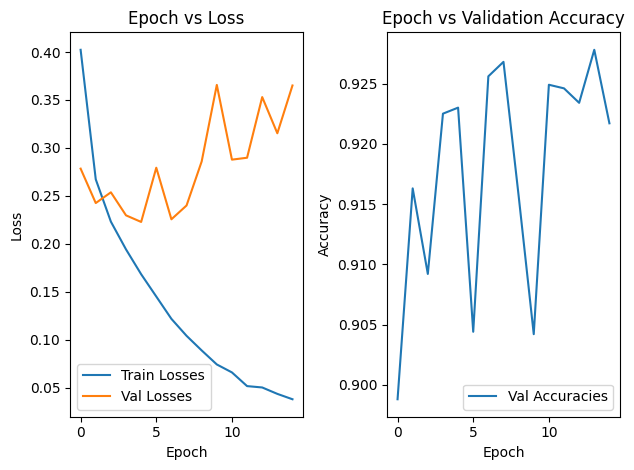

Running Tests...

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1000
           1       1.00      0.98      0.99      1000
           2       0.84      0.89      0.86      1000
           3       0.91      0.93      0.92      1000
           4       0.91      0.81      0.86      1000
           5       0.99      0.97      0.98      1000
           6       0.74      0.79      0.76      1000
           7       0.95      0.98      0.97      1000
           8       0.98      0.99      0.98      1000
           9       0.98      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

Test Accuracy: 0.92 | Test Loss: 0.4296


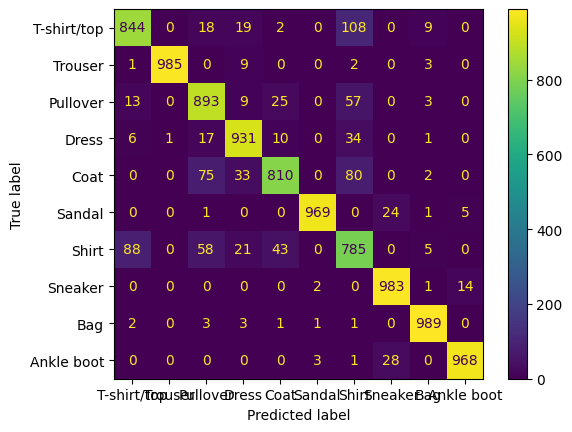



-------------------  Model 2, Optimizer 0  ---------------------


Epoch 1/15: 100%|██████████| 782/782 [00:07<00:00, 101.78it/s]


Epoch: 1/15 | Train Loss: 0.7595255259815079 | Val Loss: 1.1231038517253413 | Val Accuracy: 0.6764 | LR: N/A
Best Val Loss: 1.1231038517253413 | Saving state_dict...


Epoch 2/15: 100%|██████████| 782/782 [00:08<00:00, 93.07it/s] 


Epoch: 2/15 | Train Loss: 0.4962940082106444 | Val Loss: 0.46089129994629296 | Val Accuracy: 0.8348 | LR: N/A
Best Val Loss: 0.46089129994629296 | Saving state_dict...


...

Epoch: 13/15 | Train Loss: 0.2936866664615891 | Val Loss: 0.38388893634650356 | Val Accuracy: 0.8588 | LR: N/A


Epoch 14/15: 100%|██████████| 782/782 [00:08<00:00, 91.24it/s]


Epoch: 14/15 | Train Loss: 0.29065862245609997 | Val Loss: 0.3779121333626425 | Val Accuracy: 0.8702 | LR: N/A


Epoch 15/15: 100%|██████████| 782/782 [00:08<00:00, 91.62it/s] 


Epoch: 15/15 | Train Loss: 0.277954366086694 | Val Loss: 0.3414294748169601 | Val Accuracy: 0.8856 | LR: N/A
Total Training Time: 2.0m 21.30s
Model Training Done...



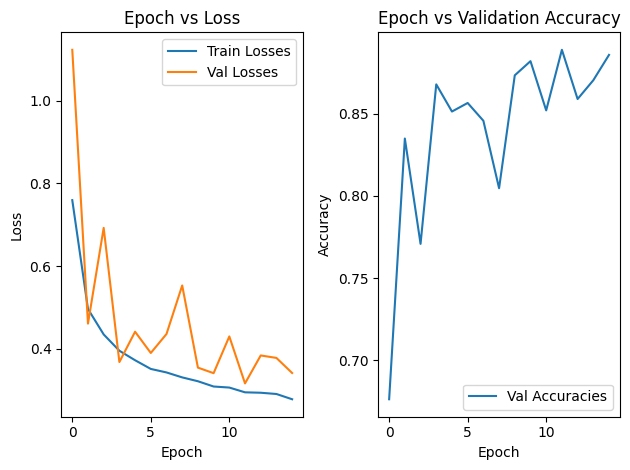

Running Tests...

              precision    recall  f1-score   support

           0       0.76      0.88      0.82      1000
           1       0.97      0.98      0.98      1000
           2       0.91      0.72      0.80      1000
           3       0.96      0.73      0.83      1000
           4       0.81      0.81      0.81      1000
           5       0.91      0.99      0.95      1000
           6       0.60      0.77      0.68      1000
           7       0.96      0.92      0.94      1000
           8       0.98      0.96      0.97      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000

Test Accuracy: 0.87 | Test Loss: 0.3788


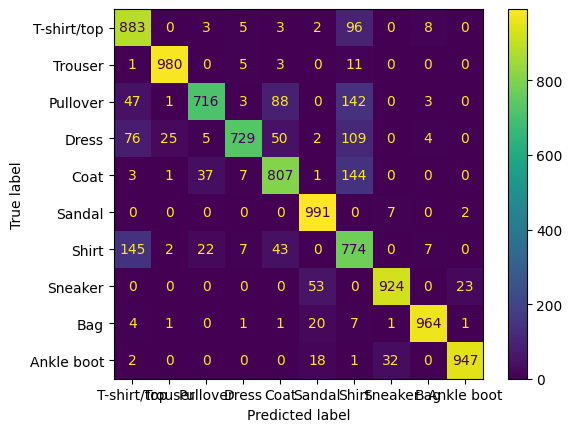



-------------------  Model 2, Optimizer 1  ---------------------


Epoch 1/15: 100%|██████████| 782/782 [00:08<00:00, 95.71it/s]


Epoch: 1/15 | Train Loss: 0.7192988633880835 | Val Loss: 1.0252131798844428 | Val Accuracy: 0.6795 | LR: N/A
Best Val Loss: 1.0252131798844428 | Saving state_dict...


Epoch 2/15: 100%|██████████| 782/782 [00:07<00:00, 100.85it/s]


Epoch: 2/15 | Train Loss: 0.47702367769559023 | Val Loss: 0.708540126586416 | Val Accuracy: 0.7561 | LR: N/A
Best Val Loss: 0.708540126586416 | Saving state_dict...


...

Epoch: 13/15 | Train Loss: 0.2856572836618442 | Val Loss: 0.3425734137084074 | Val Accuracy: 0.8762 | LR: N/A


Epoch 14/15: 100%|██████████| 782/782 [00:09<00:00, 85.17it/s] 


Epoch: 14/15 | Train Loss: 0.2856782238520777 | Val Loss: 0.3052362523925532 | Val Accuracy: 0.8937 | LR: N/A
Best Val Loss: 0.3052362523925532 | Saving state_dict...


Epoch 15/15: 100%|██████████| 782/782 [00:08<00:00, 91.51it/s]


Epoch: 15/15 | Train Loss: 0.2714162281883495 | Val Loss: 0.32482019142740093 | Val Accuracy: 0.8903 | LR: N/A
Total Training Time: 2.0m 44.21s
Model Training Done...



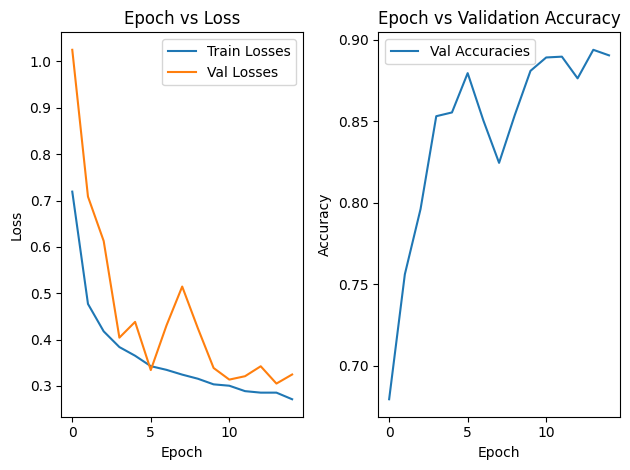

Running Tests...

              precision    recall  f1-score   support

           0       0.76      0.91      0.83      1000
           1       0.97      0.98      0.98      1000
           2       0.88      0.83      0.85      1000
           3       0.97      0.71      0.82      1000
           4       0.72      0.90      0.80      1000
           5       0.92      0.99      0.95      1000
           6       0.75      0.65      0.70      1000
           7       0.95      0.94      0.95      1000
           8       0.97      0.98      0.98      1000
           9       0.98      0.90      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000

Test Accuracy: 0.88 | Test Loss: 0.3581


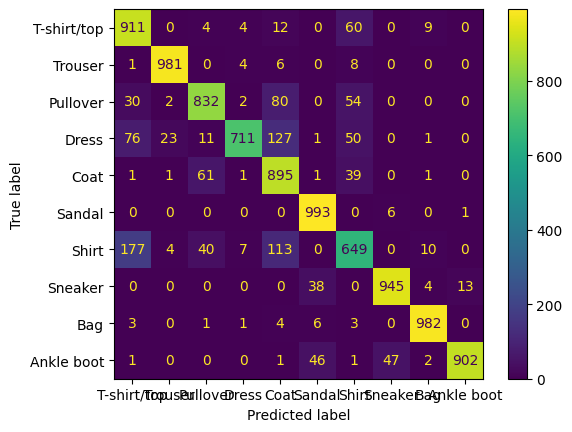



-------------------  Model 2, Optimizer 2  ---------------------


Epoch 1/15: 100%|██████████| 782/782 [00:08<00:00, 92.67it/s]


Epoch: 1/15 | Train Loss: 0.7056201096919491 | Val Loss: 0.7797755327574007 | Val Accuracy: 0.7181 | LR: N/A
Best Val Loss: 0.7797755327574007 | Saving state_dict...


Epoch 2/15: 100%|██████████| 782/782 [00:07<00:00, 99.89it/s]


Epoch: 2/15 | Train Loss: 0.4691620044924719 | Val Loss: 0.49681705948273847 | Val Accuracy: 0.8212 | LR: N/A
Best Val Loss: 0.49681705948273847 | Saving state_dict...


...

Epoch: 13/15 | Train Loss: 0.28187647377095565 | Val Loss: 0.2917569875717163 | Val Accuracy: 0.8998 | LR: N/A
Best Val Loss: 0.2917569875717163 | Saving state_dict...


Epoch 14/15: 100%|██████████| 782/782 [00:08<00:00, 87.06it/s]


Epoch: 14/15 | Train Loss: 0.2782967060308932 | Val Loss: 0.3020813136723391 | Val Accuracy: 0.8928 | LR: N/A


Epoch 15/15: 100%|██████████| 782/782 [00:08<00:00, 95.47it/s]


Epoch: 15/15 | Train Loss: 0.2656062663439899 | Val Loss: 0.31785635526772515 | Val Accuracy: 0.8899 | LR: N/A
Total Training Time: 2.0m 31.24s
Model Training Done...



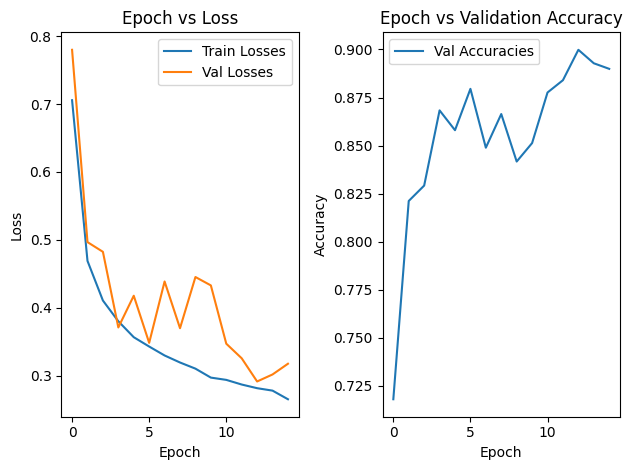

Running Tests...

              precision    recall  f1-score   support

           0       0.74      0.91      0.82      1000
           1       0.96      0.99      0.97      1000
           2       0.81      0.85      0.83      1000
           3       0.96      0.74      0.84      1000
           4       0.82      0.78      0.80      1000
           5       0.93      0.98      0.96      1000
           6       0.72      0.67      0.69      1000
           7       0.92      0.96      0.94      1000
           8       0.95      0.98      0.97      1000
           9       0.99      0.90      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Test Accuracy: 0.88 | Test Loss: 0.3588


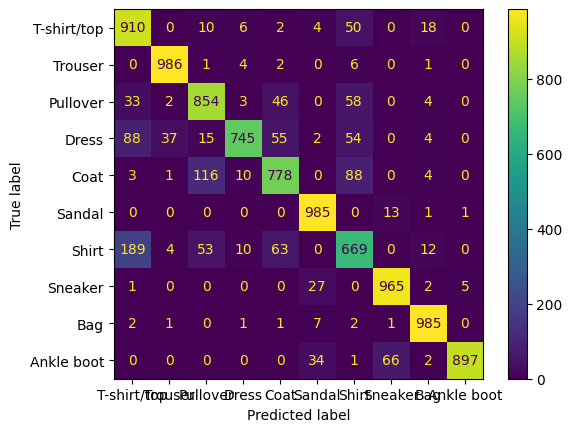



-------------------  Model 3, Optimizer 0  ---------------------


Epoch 1/15: 100%|██████████| 782/782 [00:08<00:00, 97.45it/s]


Epoch: 1/15 | Train Loss: 1.0454405125449686 | Val Loss: 0.7318965363654362 | Val Accuracy: 0.7595 | LR: N/A
Best Val Loss: 0.7318965363654362 | Saving state_dict...


Epoch 2/15: 100%|██████████| 782/782 [00:08<00:00, 91.71it/s]


Epoch: 2/15 | Train Loss: 0.6496490173403869 | Val Loss: 0.6895074310955728 | Val Accuracy: 0.7518 | LR: N/A
Best Val Loss: 0.6895074310955728 | Saving state_dict...


...

Epoch: 13/15 | Train Loss: 0.34778941699001187 | Val Loss: 0.36550558135388006 | Val Accuracy: 0.8761 | LR: N/A
Best Val Loss: 0.36550558135388006 | Saving state_dict...


Epoch 14/15: 100%|██████████| 782/782 [00:09<00:00, 85.25it/s]


Epoch: 14/15 | Train Loss: 0.33935787174326687 | Val Loss: 0.37357848972841434 | Val Accuracy: 0.8701 | LR: N/A


Epoch 15/15: 100%|██████████| 782/782 [00:08<00:00, 93.81it/s]


Epoch: 15/15 | Train Loss: 0.3346354622403374 | Val Loss: 0.34197012709963853 | Val Accuracy: 0.883 | LR: N/A
Best Val Loss: 0.34197012709963853 | Saving state_dict...
Total Training Time: 2.0m 32.99s
Model Training Done...



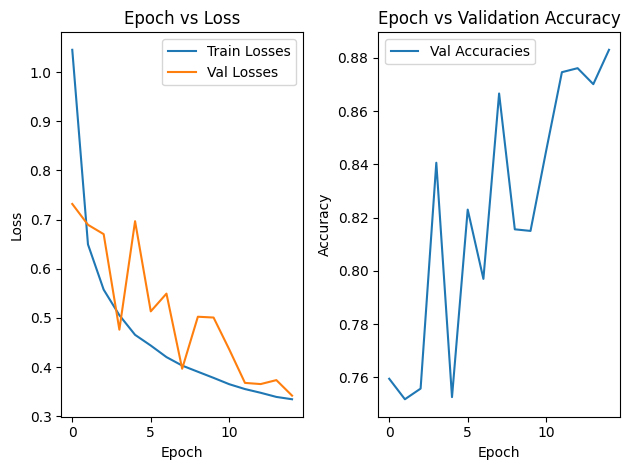

Running Tests...

              precision    recall  f1-score   support

           0       0.78      0.88      0.83      1000
           1       0.98      0.97      0.97      1000
           2       0.83      0.83      0.83      1000
           3       0.82      0.91      0.86      1000
           4       0.87      0.65      0.75      1000
           5       0.96      0.95      0.96      1000
           6       0.68      0.67      0.67      1000
           7       0.93      0.95      0.94      1000
           8       0.96      0.97      0.97      1000
           9       0.94      0.96      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

Test Accuracy: 0.87 | Test Loss: 0.3607


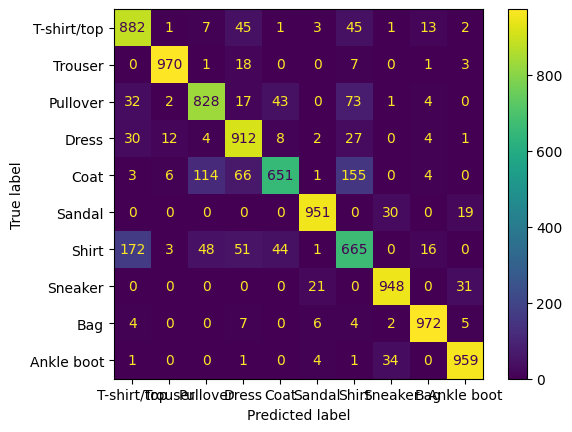



-------------------  Model 4, Optimizer 0  ---------------------


Epoch 1/15: 100%|██████████| 782/782 [00:08<00:00, 91.69it/s]


Epoch: 1/15 | Train Loss: 0.6361431191339517 | Val Loss: 0.46249938324378553 | Val Accuracy: 0.8245 | LR: N/A
Best Val Loss: 0.46249938324378553 | Saving state_dict...


Epoch 2/15: 100%|██████████| 782/782 [00:11<00:00, 70.78it/s]


Epoch: 2/15 | Train Loss: 0.4109076887674039 | Val Loss: 0.37666265808852617 | Val Accuracy: 0.8621 | LR: N/A
Best Val Loss: 0.37666265808852617 | Saving state_dict...


...

Epoch: 13/15 | Train Loss: 0.22808315057088346 | Val Loss: 0.24771984244228168 | Val Accuracy: 0.9119 | LR: N/A
Best Val Loss: 0.24771984244228168 | Saving state_dict...


Epoch 14/15: 100%|██████████| 782/782 [00:10<00:00, 77.78it/s]


Epoch: 14/15 | Train Loss: 0.22028470833492858 | Val Loss: 0.23803623628084827 | Val Accuracy: 0.9166 | LR: N/A
Best Val Loss: 0.23803623628084827 | Saving state_dict...


Epoch 15/15: 100%|██████████| 782/782 [00:09<00:00, 82.92it/s]


Epoch: 15/15 | Train Loss: 0.21236049013731578 | Val Loss: 0.24019591197086748 | Val Accuracy: 0.9167 | LR: N/A
Total Training Time: 2.0m 49.70s
Model Training Done...



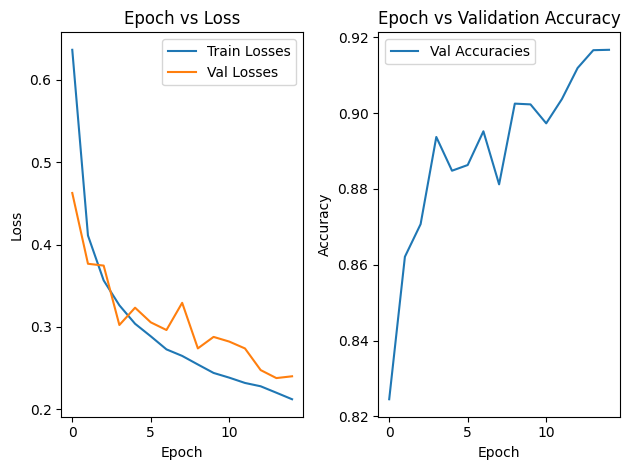

Running Tests...

              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1000
           1       0.98      0.98      0.98      1000
           2       0.92      0.83      0.87      1000
           3       0.90      0.88      0.89      1000
           4       0.79      0.91      0.85      1000
           5       0.98      0.98      0.98      1000
           6       0.76      0.74      0.75      1000
           7       0.96      0.95      0.96      1000
           8       0.96      0.99      0.97      1000
           9       0.96      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

Test Accuracy: 0.91 | Test Loss: 0.2664


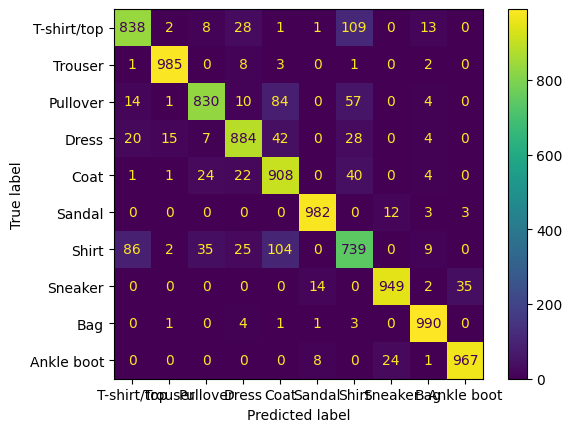



-------------------  Model 5, Optimizer 0  ---------------------


Epoch 1/15: 100%|██████████| 782/782 [00:09<00:00, 79.34it/s]


Epoch: 1/15 | Train Loss: 0.4175963542850502 | Val Loss: 0.3297093499712883 | Val Accuracy: 0.8782 | LR: 0.0005
Best Val Loss: 0.3297093499712883 | Saving state_dict...


Epoch 2/15: 100%|██████████| 782/782 [00:09<00:00, 79.30it/s]


Epoch: 2/15 | Train Loss: 0.27086634596671594 | Val Loss: 0.26640471910974783 | Val Accuracy: 0.9064 | LR: 0.0005
Best Val Loss: 0.26640471910974783 | Saving state_dict...


...

Epoch: 13/15 | Train Loss: 0.01643907093576065 | Val Loss: 0.3186636740567198 | Val Accuracy: 0.9322 | LR: 0.0000


Epoch 14/15: 100%|██████████| 782/782 [00:09<00:00, 78.74it/s]


Epoch: 14/15 | Train Loss: 0.011722626558052736 | Val Loss: 0.3357073878394855 | Val Accuracy: 0.9339 | LR: 0.0000


Epoch 15/15: 100%|██████████| 782/782 [00:09<00:00, 79.16it/s]


Epoch: 15/15 | Train Loss: 0.009654501074841103 | Val Loss: 0.34173797924000365 | Val Accuracy: 0.9356 | LR: 0.0000
Total Training Time: 2.0m 46.35s
Model Training Done...



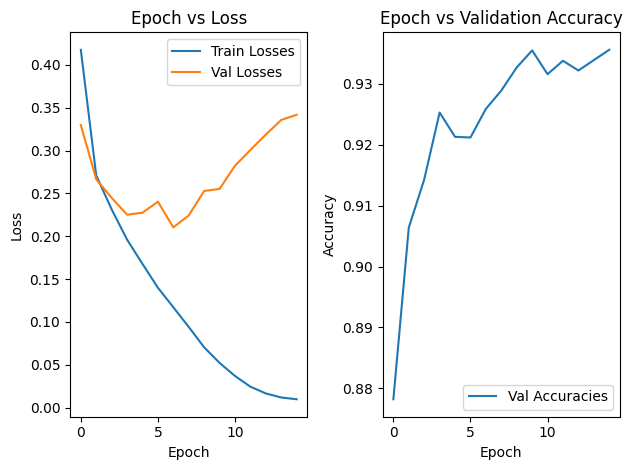

Running Tests...

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1000
           1       0.99      0.98      0.99      1000
           2       0.89      0.90      0.90      1000
           3       0.93      0.93      0.93      1000
           4       0.89      0.89      0.89      1000
           5       0.99      0.99      0.99      1000
           6       0.79      0.80      0.79      1000
           7       0.97      0.98      0.97      1000
           8       0.99      0.99      0.99      1000
           9       0.98      0.97      0.98      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

Test Accuracy: 0.93 | Test Loss: 0.3914


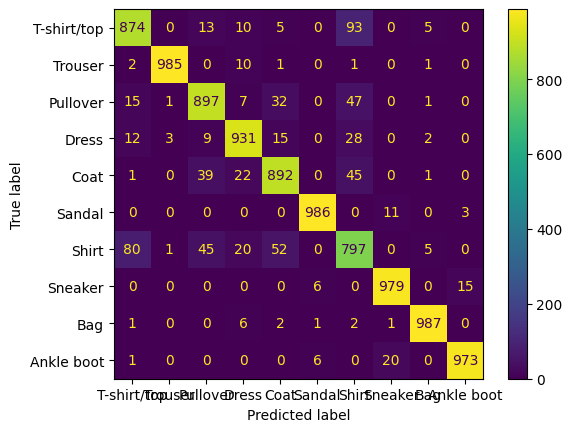



-------------------  Model 6, Optimizer 0  ---------------------


Epoch 1/15: 100%|██████████| 782/782 [00:09<00:00, 81.39it/s]


Epoch: 1/15 | Train Loss: 0.4507322784351266 | Val Loss: 0.3028455088567582 | Val Accuracy: 0.8882 | LR: 0.0005
Best Val Loss: 0.3028455088567582 | Saving state_dict...


Epoch 2/15: 100%|██████████| 782/782 [00:08<00:00, 91.36it/s]


Epoch: 2/15 | Train Loss: 0.30856044100754704 | Val Loss: 0.26449923706092654 | Val Accuracy: 0.9031 | LR: 0.0005
Best Val Loss: 0.26449923706092654 | Saving state_dict...


...

Epoch: 13/15 | Train Loss: 0.08902016782399524 | Val Loss: 0.19527922188685198 | Val Accuracy: 0.9351 | LR: 0.0000


Epoch 14/15: 100%|██████████| 782/782 [00:09<00:00, 83.79it/s]


Epoch: 14/15 | Train Loss: 0.0814482820210764 | Val Loss: 0.19742166721944215 | Val Accuracy: 0.9342 | LR: 0.0000


Epoch 15/15: 100%|██████████| 782/782 [00:09<00:00, 80.19it/s]


Epoch: 15/15 | Train Loss: 0.07784330092199013 | Val Loss: 0.20028695267192118 | Val Accuracy: 0.9338 | LR: 0.0000
Total Training Time: 2.0m 39.64s
Model Training Done...



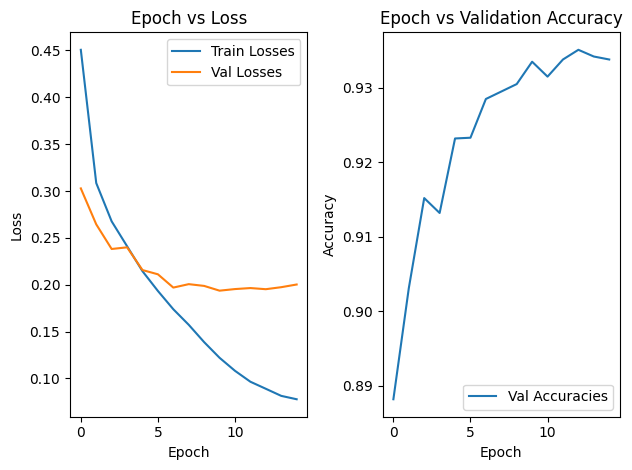

Running Tests...

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      1000
           1       0.99      0.98      0.99      1000
           2       0.89      0.89      0.89      1000
           3       0.92      0.93      0.93      1000
           4       0.88      0.89      0.88      1000
           5       0.99      0.99      0.99      1000
           6       0.79      0.78      0.78      1000
           7       0.97      0.98      0.97      1000
           8       0.99      0.98      0.99      1000
           9       0.98      0.97      0.98      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

Test Accuracy: 0.93 | Test Loss: 0.2267


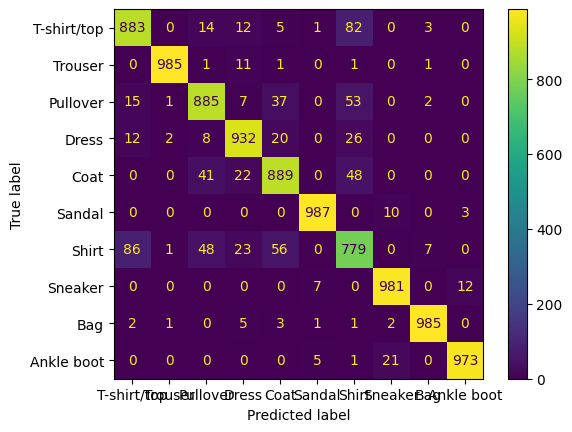

In [34]:
num_epochs = 15

for name, model in models.items():
    for optim_index, optimizer in enumerate(model.optimizers):
        print(f"\n\n-------------------  {name}, Optimizer {optim_index}  ---------------------")
        try:
            lr_scheduler = model.lr_scheduler(optimizer, T_max=num_epochs, eta_min=1e-6)
        except AttributeError:
            lr_scheduler = None
        best_model_state, train_losses, val_losses, val_accs, elapsed = train_model(model, num_epochs, criterion, optimizer, train_dataloader, val_dataloader, scheduler=lr_scheduler)

        print("Model Training Done...\n")
        plot_results(train_losses, val_losses, val_accs)

        print("Running Tests...\n")
        test_acc = run_test(model, best_model_state, test_dataloader, criterion)

        model_stats["Model"].append(name)
        model_stats["Optimizer"].append(f"Optimizer {optim_index}")
        model_stats["Accuracy"].append(test_acc)
        model_stats["Train Time"].append(elapsed)

        reset_model_params(model)

In [35]:
import pandas as pd

summary = pd.DataFrame(model_stats)
summary

,Model,Optimizer,Accuracy,Train Time
0,Model 1,Optimizer 0,0.9157,164.466784
1,Model 2,Optimizer 0,0.8715,141.296475
2,Model 2,Optimizer 1,0.8801,164.214443
3,Model 2,Optimizer 2,0.8774,151.241300
4,Model 3,Optimizer 0,0.8738,152.991076
5,Model 4,Optimizer 0,0.9072,169.699512
6,Model 5,Optimizer 0,0.9301,166.350800
7,Model 6,Optimizer 0,0.9279,159.636007


* Even though Model 5 has a better accuracy than Model 6, Model 6 has a significantly better test loss of 0.2267 compared to Model 5's 0.3914.

### Next Steps:
* More models and optimizers
* Save validation loss into summary
* DO NOT SELECT MODELS BASED ON THEIR TEST ACCURACIES. REPLACE TEST ACCURACY IN SUMMARY WITH VALIDATION ACCURACY. THIS IS A SOURCE OF DATA LEAKAGE.
* Always use GPU when training these. All 8 different training loops of 15 epochs took a total of 21 minutes with T4 GPU. I did one full training of 15 epochs for model 6 yesterday for over 20 minutes.